In [1]:
import os
import numpy as np
import pandas as pd

os.chdir("/home/abid/binta/walkability_abid/")

from config.grid import GRID_OUT_CSV
from config.dynamic_ws import DYNAMIC_DATA_PATH
from src.composite_score import compute_conf_dyn
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df_rf = pd.read_csv('redfin_score/redfin.csv')
df_grid = pd.read_csv(GRID_OUT_CSV)



In [3]:
# merge data
df_rf = df_rf.rename(columns={'Walk Score': 'walkscore_redfin'})
df_grid = df_grid.rename(columns={'lat_center': 'lat', 'lon_center': 'lon'})
for d in (df_grid, df_rf):
    d["lat_r6"] = d["lat"].round(6)
    d["lon_r6"] = d["lon"].round(6)
df_merge = df_grid.merge( df_rf, on=["lat_r6", "lon_r6"], how="left", suffixes=("", "_redfin") )
matched_pct = 100 * df_merge["walkscore_redfin"].notna().mean()
print(f"Matched Redfin coverage: {matched_pct:.1f}%")


Matched Redfin coverage: 100.0%


In [4]:
df_merge = df_merge.dropna(subset=[
                                    "walkscore_redfin", 
                                    "walkscore_composite",
                                    "walkscore_static", 
                                    "walkscore_dyn", 
                                    "lat", 
                                    "lon"
                                    ]
                          ).copy()

In [5]:
def metrics(y, x):
    y = pd.to_numeric(y, errors='coerce')
    x = pd.to_numeric(x, errors='coerce')
    m = y.notna() & x.notna()
    y, x = y[m], x[m]
    pear = float(y.corr(x, method="pearson"))
    spear = float(y.corr(x, method="spearman"))
    mae = float(mean_absolute_error(y, x))
    rmse = float(np.sqrt(mean_squared_error(y, x)))
    bias = float((x - y).mean())
    return pd.Series({"pearson_r": round(pear,3), "spearman_rho": round(spear,3),
                      "MAE": round(mae,2), "RMSE": round(rmse,2), "Bias(pred-true)": round(bias,2), "n": len(y)})


In [6]:
# 
m10 = pd.DataFrame({
    "Composite vs Redfin (10m)": metrics(df_merge['walkscore_redfin'], df_merge['walkscore_composite']),
    "Static vs Redfin (10m)"   : metrics(df_merge['walkscore_redfin'], df_merge['walkscore_static']),
    "Dynamic vs Redfin (10m)"  : metrics(df_merge['walkscore_redfin'], df_merge['walkscore_dyn']),
}).T
print(m10)

                           pearson_r  spearman_rho    MAE   RMSE  \
Composite vs Redfin (10m)      0.337         0.302  12.22  15.03   
Static vs Redfin (10m)         0.409         0.338  17.59  20.84   
Dynamic vs Redfin (10m)        0.213         0.242  16.49  20.65   

                           Bias(pred-true)       n  
Composite vs Redfin (10m)            -3.49  1388.0  
Static vs Redfin (10m)              -14.11  1388.0  
Dynamic vs Redfin (10m)               7.21  1388.0  


In [7]:
g = df_merge.copy()
g["lat3"] = g['lat'].round(3)
g["lon3"] = g['lon'].round(3)

agg = g.groupby(["lat3","lon3"]).agg({
    'walkscore_redfin':"mean", 'walkscore_composite':"mean", 'walkscore_static':"mean", 'walkscore_dyn':"mean",
}).reset_index(drop=True)

m100 = pd.DataFrame({
    "Composite vs Redfin (~100m)": metrics(agg['walkscore_redfin'], agg['walkscore_composite']),
    "Static vs Redfin (~100m)"   : metrics(agg['walkscore_redfin'], agg['walkscore_static']),
    "Dynamic vs Redfin (~100m)"  : metrics(agg['walkscore_redfin'], agg['walkscore_dyn']),
}).T
print(m100)

                             pearson_r  spearman_rho    MAE   RMSE  \
Composite vs Redfin (~100m)      0.457         0.443  10.97  13.05   
Static vs Redfin (~100m)         0.497         0.447  16.82  19.92   
Dynamic vs Redfin (~100m)        0.271         0.304  13.68  16.88   

                             Bias(pred-true)     n  
Composite vs Redfin (~100m)            -4.09  66.0  
Static vs Redfin (~100m)              -14.08  66.0  
Dynamic vs Redfin (~100m)               6.26  66.0  


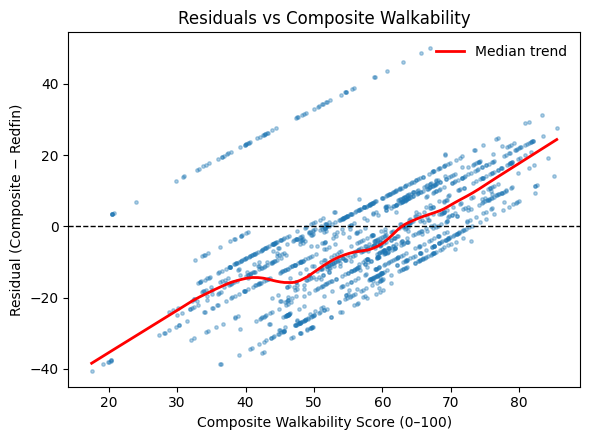

In [8]:
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

df_merge["residual_comp"] = df_merge['walkscore_composite'] - df_merge['walkscore_redfin']

x = df_merge['walkscore_composite']
y = df_merge["residual_comp"]



plt.figure(figsize=(6,4.5))
plt.scatter(
    x, y,
    s=6, alpha=0.35, rasterized=True
)

# Reference line
plt.axhline(0, color='k', lw=1, linestyle='--')

# LOWESS trend (optional but recommended)
mask = np.isfinite(x) & np.isfinite(y)
trend = lowess(y[mask], x[mask], frac=0.25)
plt.plot(trend[:,0], trend[:,1], color='red', lw=2, label="Median trend")

plt.xlabel("Composite Walkability Score (0–100)")
plt.ylabel("Residual (Composite − Redfin)")
plt.title("Residuals vs Composite Walkability")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

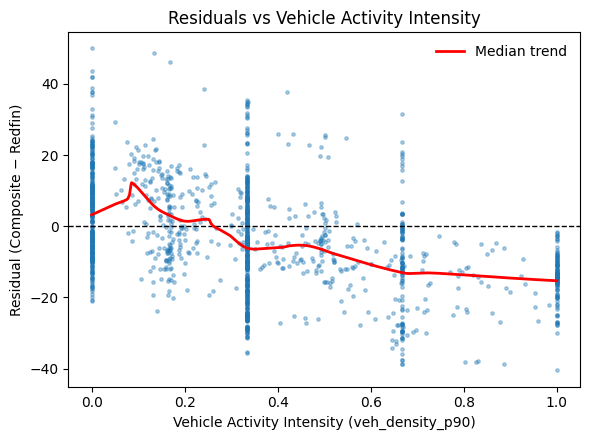

In [9]:
x = pd.to_numeric(df_merge["veh_density_p90"], errors='coerce')
y = df_merge["residual_comp"]

plt.figure(figsize=(6,4.5))
plt.scatter(
    x, y,
    s=6, alpha=0.35, rasterized=True
)

plt.axhline(0, color='k', lw=1, linestyle='--')

# LOWESS trend
mask = np.isfinite(x) & np.isfinite(y)
trend = lowess(y[mask], x[mask], frac=0.35)
plt.plot(trend[:,0], trend[:,1], color='red', lw=2, label="Median trend")

plt.xlabel("Vehicle Activity Intensity (veh_density_p90)")
plt.ylabel("Residual (Composite − Redfin)")
plt.title("Residuals vs Vehicle Activity Intensity")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [15]:
def get_quad(df_merge):
        
    risk_series = df_merge["veh_density_p90"] if "veh_density_p90" in df_merge.columns else pd.Series(np.nan, index=df_merge.index)
    walk_thr = float(df_merge["walkscore_composite"].median(skipna=True))
    risk_thr = float(pd.to_numeric(risk_series, errors='coerce').median(skipna=True))

    def qlabel(w, r):
        """"
        """
        if pd.isna(r): return "Unclassified"
        if w >= walk_thr and r < risk_thr:   return 0
        if w >= walk_thr and r >= risk_thr:  return 1
        if w <  walk_thr and r >= risk_thr:  return 2
        return 3

    df_merge["quad_class"] = [qlabel(w, r) for w, r in zip(df_merge["walkscore_composite"], risk_series)]

    def metrics_series(sub):
        return metrics(sub["walkscore_redfin"], sub["walkscore_composite"])
    by_quad = df_merge.dropna(subset=["walkscore_redfin", "walkscore_composite"]).groupby("quad_class").apply(metrics_series)
    return df_merge, by_quad


In [16]:
df_merge, by_quad = get_quad(df_merge)

/tmp/ipykernel_2608448/1314744382.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_quad = df_merge.dropna(subset=["walkscore_redfin", "walkscore_composite"]).groupby("quad_class").apply(metrics_series)


In [29]:
from src.plotter import plot_grid
from matplotlib.colors import ListedColormap
import branca.colormap as cm

colors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8'] 

# 2. Create the discrete colormap
cmap = cm.linear.RdYlGn_09.scale(0, 3).to_step(4)
plot_grid(df_merge, "quad.html","quad_class","Quad Class", cmap=cmap)